<a href="https://colab.research.google.com/github/amtom2004/Deep-Learning-for-Computer-Vision/blob/main/Realtionship.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

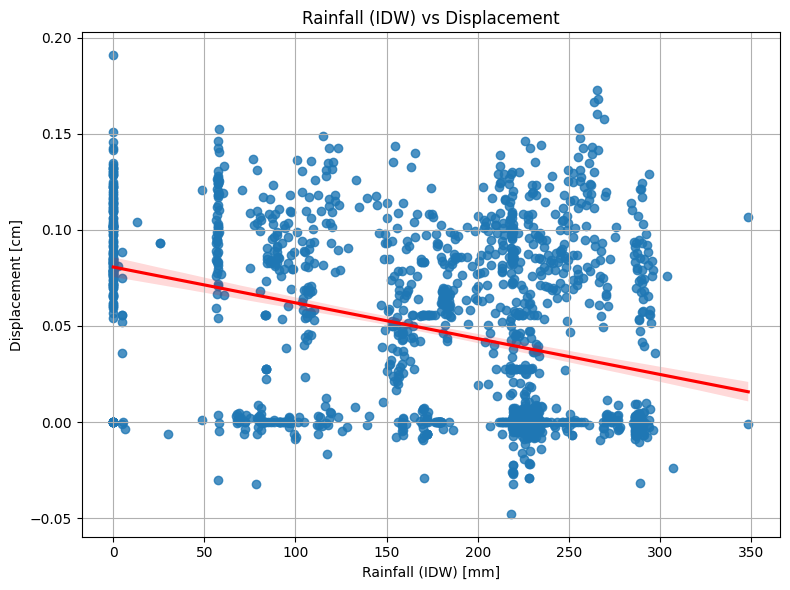

Pearson Correlation: -0.328
Spearman Correlation: -0.304

--- Linear Regression ---
Equation: Displacement = -0.0002 * Rainfall + 0.0807
R-squared: 0.1078


In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import pearsonr, spearmanr
from sklearn.linear_model import LinearRegression
import numpy as np

# Load your Excel file (update the path if needed)
file_path = "Landslide Data Final 10-04-25.xlsx"
df = pd.read_excel(file_path)

# Clean column names (remove extra spaces)
df.columns = df.columns.str.strip()

# Extract the relevant columns
df = df[['DISPLACEMENT (cm)', 'IDW (mm)']].dropna()

# Rename for convenience
df.columns = ['Displacement_cm', 'Rainfall_IDW_mm']

# ----------------------------------------
# 1. Scatter Plot with Regression Line
# ----------------------------------------
plt.figure(figsize=(8, 6))
sns.regplot(x='Rainfall_IDW_mm', y='Displacement_cm', data=df, line_kws={"color": "red"})
plt.title('Rainfall (IDW) vs Displacement')
plt.xlabel('Rainfall (IDW) [mm]')
plt.ylabel('Displacement [cm]')
plt.grid(True)
plt.tight_layout()
plt.show()

# ----------------------------------------
# 2. Correlation
# ----------------------------------------
pearson_corr, _ = pearsonr(df['Rainfall_IDW_mm'], df['Displacement_cm'])
spearman_corr, _ = spearmanr(df['Rainfall_IDW_mm'], df['Displacement_cm'])
print(f"Pearson Correlation: {pearson_corr:.3f}")
print(f"Spearman Correlation: {spearman_corr:.3f}")

# ----------------------------------------
# 3. Linear Regression
# ----------------------------------------
X = df[['Rainfall_IDW_mm']].values
y = df['Displacement_cm'].values

model = LinearRegression()
model.fit(X, y)

slope = model.coef_[0]
intercept = model.intercept_
r_squared = model.score(X, y)

print("\n--- Linear Regression ---")
print(f"Equation: Displacement = {slope:.4f} * Rainfall + {intercept:.4f}")
print(f"R-squared: {r_squared:.4f}")

Multivariate Regression R-squared: 0.2180


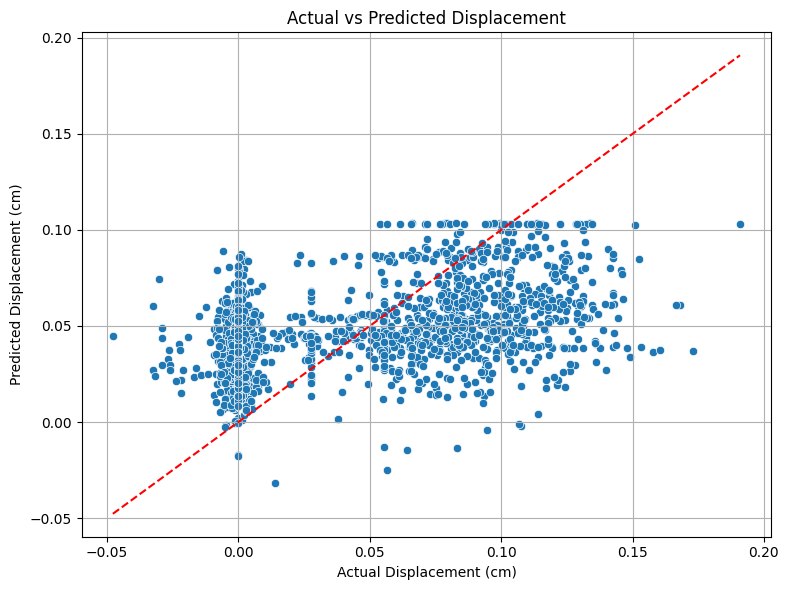

In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import make_pipeline
from sklearn.metrics import r2_score

# Load and clean data
file_path = "Landslide Data Final 10-04-25.xlsx"
df = pd.read_excel(file_path)
df.columns = df.columns.str.strip()

# Keep relevant columns
df = df[['DISPLACEMENT (cm)', 'IDW (mm)', 'SLOPE (degrees)', 'LITHOLOGY']].dropna()

# Rename for convenience
df.columns = ['Displacement_cm', 'Rainfall_IDW_mm', 'Slope_deg', 'Lithology']

# Define predictors and target
X = df[['Rainfall_IDW_mm', 'Slope_deg', 'Lithology']]
y = df['Displacement_cm']

# One-hot encode 'Lithology' (categorical feature)
preprocessor = ColumnTransformer([
    ('cat', OneHotEncoder(drop='first'), ['Lithology'])
], remainder='passthrough')

# Build regression pipeline
model = make_pipeline(preprocessor, LinearRegression())

# Fit the model
model.fit(X, y)

# Predict and evaluate
y_pred = model.predict(X)
r2 = r2_score(y, y_pred)

print(f"Multivariate Regression R-squared: {r2:.4f}")

# Optional: plot predicted vs actual
plt.figure(figsize=(8, 6))
sns.scatterplot(x=y, y=y_pred)
plt.xlabel("Actual Displacement (cm)")
plt.ylabel("Predicted Displacement (cm)")
plt.title("Actual vs Predicted Displacement")
plt.plot([y.min(), y.max()], [y.min(), y.max()], 'r--')
plt.grid(True)
plt.tight_layout()
plt.show()

In [3]:
from scipy.stats import f_oneway
import pandas as pd

# Assume df already loaded and cleaned

# Create rainfall bins (e.g., tertiles: low, medium, high)
df['Rainfall_Group'] = pd.qcut(df['Rainfall_IDW_mm'], q=3, labels=['Low', 'Medium', 'High'])

# Extract displacement values for each group
low = df[df['Rainfall_Group'] == 'Low']['Displacement_cm']
med = df[df['Rainfall_Group'] == 'Medium']['Displacement_cm']
high = df[df['Rainfall_Group'] == 'High']['Displacement_cm']

# Run ANOVA
f_stat, p_value = f_oneway(low, med, high)
print(f"ANOVA F-statistic: {f_stat:.4f}, p-value: {p_value:.4f}")

ANOVA F-statistic: 82.2447, p-value: 0.0000


In [4]:
from statsmodels.stats.multicomp import pairwise_tukeyhsd

# Run Tukey HSD test
tukey = pairwise_tukeyhsd(endog=df['Displacement_cm'], groups=df['Rainfall_Group'], alpha=0.05)
print(tukey)

Multiple Comparison of Means - Tukey HSD, FWER=0.05
group1 group2 meandiff p-adj  lower   upper  reject
---------------------------------------------------
  High    Low   0.0316   0.0   0.025  0.0382   True
  High Medium   0.0011 0.913 -0.0054  0.0077  False
   Low Medium  -0.0305   0.0  -0.037 -0.0239   True
---------------------------------------------------


<ipython-input-5-c9fcccb650d7>:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Rainfall_Group', y='Displacement_cm', data=df, palette="Set2")


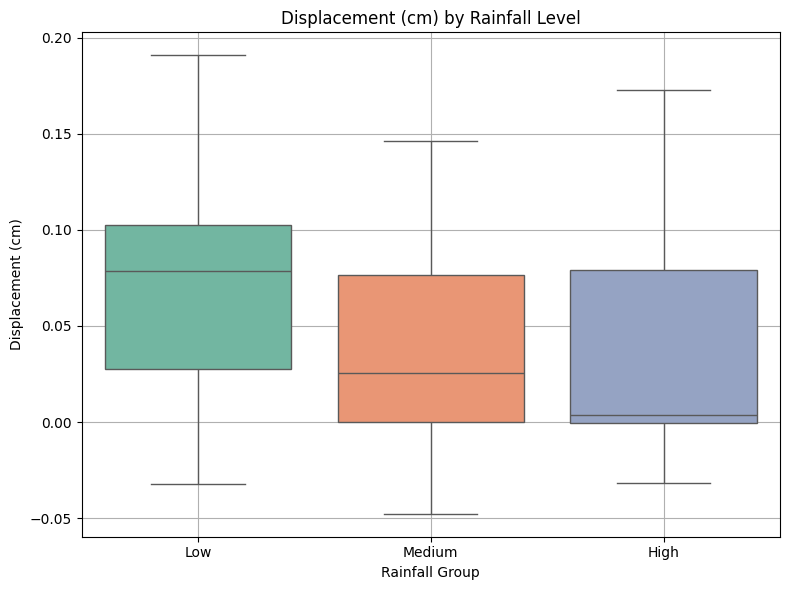

In [5]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))
sns.boxplot(x='Rainfall_Group', y='Displacement_cm', data=df, palette="Set2")
plt.title("Displacement (cm) by Rainfall Level")
plt.xlabel("Rainfall Group")
plt.ylabel("Displacement (cm)")
plt.grid(True)
plt.tight_layout()
plt.show()

In [6]:
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import OneHotEncoder, PolynomialFeatures
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

# Create interaction term: Rainfall * Slope
df['Rainfall_Slope_Interaction'] = df['Rainfall_IDW_mm'] * df['Slope_deg']

# Define predictors and target
X = df[['Rainfall_IDW_mm', 'Slope_deg', 'Lithology', 'Rainfall_Slope_Interaction']]
y = df['Displacement_cm']

# One-hot encode Lithology
preprocessor = ColumnTransformer([
    ('cat', OneHotEncoder(drop='first'), ['Lithology'])
], remainder='passthrough')

# Build pipeline
model = Pipeline([
    ('preprocess', preprocessor),
    ('regression', LinearRegression())
])

# Fit the model
model.fit(X, y)

# Predict and evaluate
y_pred = model.predict(X)
from sklearn.metrics import r2_score
r2 = r2_score(y, y_pred)

print(f"R-squared with Rainfall × Slope interaction: {r2:.4f}")

R-squared with Rainfall × Slope interaction: 0.2286


ANOVA F-statistic: 50.2411, p-value: 0.0000

Tukey HSD Results:
Multiple Comparison of Means - Tukey HSD, FWER=0.05 
group1 group2 meandiff p-adj   lower   upper  reject
----------------------------------------------------
  High    Low   0.0269    0.0  0.0202  0.0336   True
  High Medium    0.005 0.1821 -0.0017  0.0117  False
   Low Medium  -0.0218    0.0 -0.0285 -0.0152   True
----------------------------------------------------


<ipython-input-7-5529dcbfe02d>:32: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Slope_Group', y='Displacement_cm', data=df, palette='Pastel2')


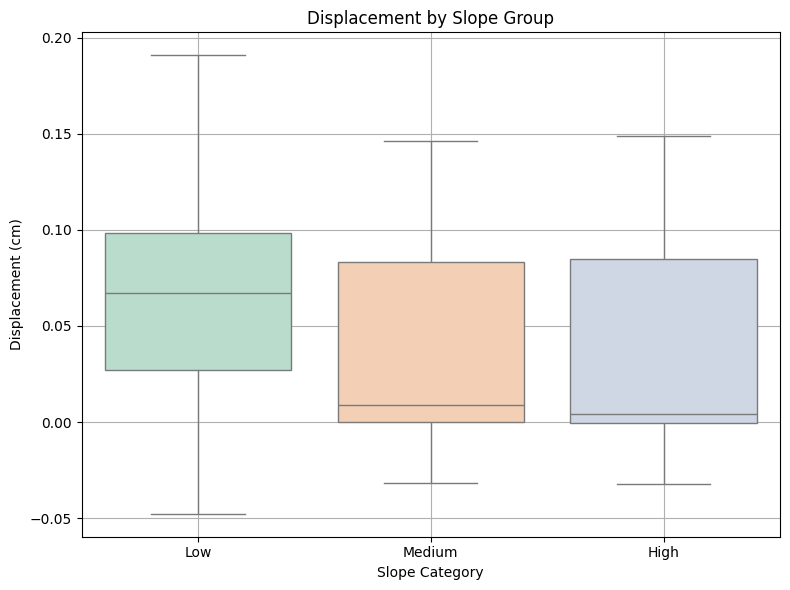

In [7]:
import pandas as pd
from scipy.stats import f_oneway
from statsmodels.stats.multicomp import pairwise_tukeyhsd
import seaborn as sns
import matplotlib.pyplot as plt

# Load and clean data
df = pd.read_excel("Landslide Data Final 10-04-25.xlsx")
df.columns = df.columns.str.strip()
df = df[['DISPLACEMENT (cm)', 'SLOPE (degrees)']].dropna()

# Rename for convenience
df.columns = ['Displacement_cm', 'Slope_deg']

# 1. Create slope categories (tertiles: Low, Medium, High)
df['Slope_Group'] = pd.qcut(df['Slope_deg'], q=3, labels=['Low', 'Medium', 'High'])

# 2. Run ANOVA
groups = [df[df['Slope_Group'] == g]['Displacement_cm'] for g in ['Low', 'Medium', 'High']]
f_stat, p_value = f_oneway(*groups)
print(f"ANOVA F-statistic: {f_stat:.4f}, p-value: {p_value:.4f}")

# 3. Tukey HSD Post-hoc Test
tukey = pairwise_tukeyhsd(endog=df['Displacement_cm'],
                          groups=df['Slope_Group'],
                          alpha=0.05)
print("\nTukey HSD Results:")
print(tukey)

# 4. Optional: Boxplot to visualize
plt.figure(figsize=(8, 6))
sns.boxplot(x='Slope_Group', y='Displacement_cm', data=df, palette='Pastel2')
plt.title("Displacement by Slope Group")
plt.xlabel("Slope Category")
plt.ylabel("Displacement (cm)")
plt.grid(True)
plt.tight_layout()
plt.show()


--- Rainfall vs Displacement ---
ANOVA F-statistic: 121.6678, p-value: 0.0000

Tukey HSD (Rainfall):
Multiple Comparison of Means - Tukey HSD, FWER=0.05 
group1 group2 meandiff p-adj   lower   upper  reject
----------------------------------------------------
  High    Low   0.0435    0.0   0.036  0.0509   True
  High Medium   0.0012 0.9227 -0.0063  0.0087  False
   Low Medium  -0.0423    0.0 -0.0497 -0.0348   True
----------------------------------------------------


<ipython-input-8-41fdad886a3e>:40: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Rainfall_Group', y='Displacement_cm', data=df, palette='Set2')


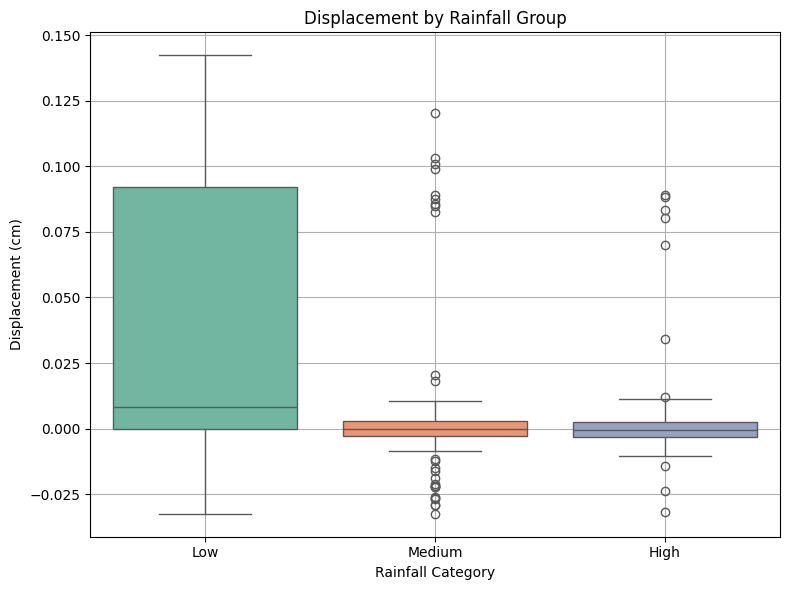


--- Slope vs Displacement ---
ANOVA F-statistic: 2.4747, p-value: 0.0850

Tukey HSD (Slope):
Multiple Comparison of Means - Tukey HSD, FWER=0.05
group1 group2 meandiff p-adj   lower  upper  reject
---------------------------------------------------
  High    Low    0.001 0.9589 -0.0077 0.0098  False
  High Medium   0.0076 0.1012 -0.0011 0.0164  False
   Low Medium   0.0066 0.1795 -0.0022 0.0154  False
---------------------------------------------------


<ipython-input-8-41fdad886a3e>:67: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Slope_Group', y='Displacement_cm', data=df, palette='Pastel2')


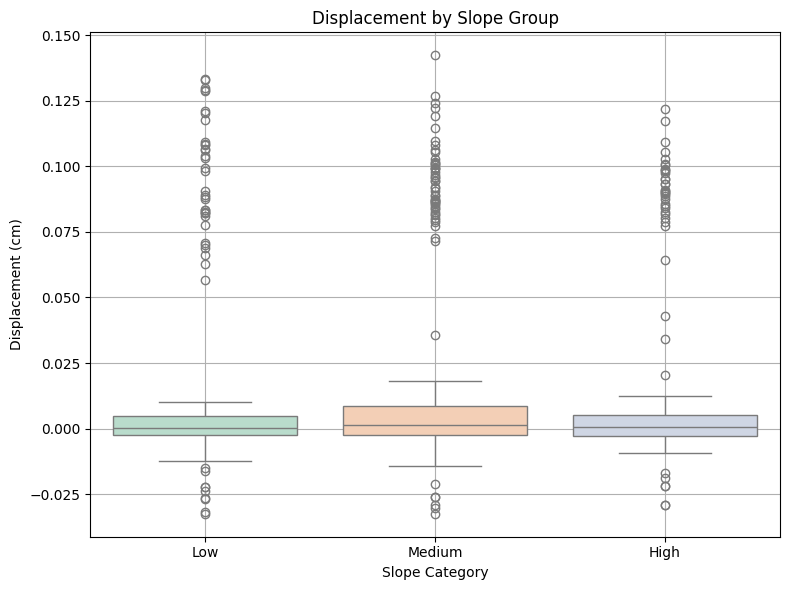

In [8]:
import pandas as pd
from scipy.stats import f_oneway
from statsmodels.stats.multicomp import pairwise_tukeyhsd
import seaborn as sns
import matplotlib.pyplot as plt

# Load data
df = pd.read_excel("/content/LANDSLIDE ONLY FINAL DATA.xlsx")
df.columns = df.columns.str.strip()  # Clean column names

# Rename for simplicity
df.rename(columns={
    'DISPLACEMENT (cm)': 'Displacement_cm',
    'IDW (mm)': 'Rainfall_IDW_mm',
    'SLOPE (degrees)': 'Slope_deg'
}, inplace=True)

# Drop rows with missing values for relevant columns
df = df[['Displacement_cm', 'Rainfall_IDW_mm', 'Slope_deg']].dropna()

# -----------------------------
# 1️⃣ ANOVA + Tukey: Rainfall vs Displacement
# -----------------------------
# Create rainfall group (tertiles)
df['Rainfall_Group'] = pd.qcut(df['Rainfall_IDW_mm'], q=3, labels=['Low', 'Medium', 'High'])

# ANOVA
rainfall_groups = [df[df['Rainfall_Group'] == g]['Displacement_cm'] for g in ['Low', 'Medium', 'High']]
f_rainfall, p_rainfall = f_oneway(*rainfall_groups)
print(f"\n--- Rainfall vs Displacement ---")
print(f"ANOVA F-statistic: {f_rainfall:.4f}, p-value: {p_rainfall:.4f}")

# Tukey HSD
tukey_rain = pairwise_tukeyhsd(df['Displacement_cm'], df['Rainfall_Group'])
print("\nTukey HSD (Rainfall):")
print(tukey_rain)

# Boxplot
plt.figure(figsize=(8, 6))
sns.boxplot(x='Rainfall_Group', y='Displacement_cm', data=df, palette='Set2')
plt.title("Displacement by Rainfall Group")
plt.xlabel("Rainfall Category")
plt.ylabel("Displacement (cm)")
plt.grid(True)
plt.tight_layout()
plt.show()

# -----------------------------
# 2️⃣ ANOVA + Tukey: Slope vs Displacement
# -----------------------------
# Create slope group (tertiles)
df['Slope_Group'] = pd.qcut(df['Slope_deg'], q=3, labels=['Low', 'Medium', 'High'])

# ANOVA
slope_groups = [df[df['Slope_Group'] == g]['Displacement_cm'] for g in ['Low', 'Medium', 'High']]
f_slope, p_slope = f_oneway(*slope_groups)
print(f"\n--- Slope vs Displacement ---")
print(f"ANOVA F-statistic: {f_slope:.4f}, p-value: {p_slope:.4f}")

# Tukey HSD
tukey_slope = pairwise_tukeyhsd(df['Displacement_cm'], df['Slope_Group'])
print("\nTukey HSD (Slope):")
print(tukey_slope)

# Boxplot
plt.figure(figsize=(8, 6))
sns.boxplot(x='Slope_Group', y='Displacement_cm', data=df, palette='Pastel2')
plt.title("Displacement by Slope Group")
plt.xlabel("Slope Category")
plt.ylabel("Displacement (cm)")
plt.grid(True)
plt.tight_layout()
plt.show()